# Neural PDE Laboratory · 06
## Fourier features and adaptive collocation

Experiments **10–11** of the laboratory. This notebook is self-contained:
run it in a fresh kernel; no earlier notebook or saved result is required.

[All seven notebooks](Neural_PDE_Laboratory.ipynb) · [Setup and guide](NOTEBOOK_README.md)

Install `experiments/requirements-notebook.txt`, then select **Restart Kernel and
Run All Cells**. The supplied static plots and diagnostics can be read on GitHub.
Interactive explorers are separate, self-contained HTML files in `notebook_outputs/`;
download that folder and open `index.html` in a browser, or regenerate them locally.

Python 3.11+; CPU / float64. Set `RUN_MODE = "thorough"` for longer training runs.

**Notation:** $u$ is the reference state, $u_\theta$ the neural state,
$r_\theta=\mathcal L u_\theta-f$, $\mathcal J$ a continuous residual loss,
$\widehat{\mathcal J}$ its numerical approximation, and $\mathcal E$ an energy.
A hat indicates sampling or quadrature. We check solution error separately from training loss.

In [1]:
# Uncomment only if these packages are missing, then restart the kernel.
# %pip install "numpy>=2.0" scipy matplotlib "torch>=2.2" "plotly>=5.24,<7" ipython

In [2]:
from pathlib import Path
import copy, io, json, math, platform, time
import numpy as np
import scipy
from scipy.linalg import solve_banded
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import torch
from torch import nn
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown, Image

RUN_MODE = "quick"               # "quick" or "thorough"
SEED = 7
OUTPUT_DIR = Path.cwd() / "notebook_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
NOTEBOOK_START = time.perf_counter()
metrics = []
FIGURE_NAMES, INTERACTIVE_NAMES = [], []
assert RUN_MODE in {"quick", "thorough"}
torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
torch.manual_seed(SEED)
np.random.seed(SEED)
BUDGET = {"adam_1d": 900, "lbfgs_1d": 180, "adam_2d": 1100,
          "lbfgs_2d": 260, "boundary_adam": 900}
if RUN_MODE == "thorough":
    BUDGET = {key: 2 * value for key, value in BUDGET.items()}
versions = {"python": platform.python_version(), "numpy": np.__version__,
            "scipy": scipy.__version__, "matplotlib": matplotlib.__version__,
            "torch": torch.__version__, "plotly": plotly.__version__}
print(json.dumps(versions, indent=2))
print(f"CPU / float64 / seed {SEED} / {RUN_MODE} mode")

{
  "python": "3.13.9",
  "numpy": "2.4.2",
  "scipy": "1.17.0",
  "matplotlib": "3.10.8",
  "torch": "2.10.0",
  "plotly": "6.9.0"
}
CPU / float64 / seed 7 / quick mode


## Reading and saving the plots

Static figures are saved as PNG and PDF and embedded in this notebook. Interactive
plots are saved as offline HTML files: open their links locally to rotate, zoom,
and animate them. GitHub displays the static figures without executing JavaScript.

In [3]:
palette = {"navy": "#10243A", "teal": "#00A6A6", "orange": "#F28C45",
           "pink": "#DC4778", "blue": "#4878D0", "ink": "#183449", "muted": "#63788A"}
plt.rcParams.update({
    "figure.facecolor": "#F7FAFC", "axes.facecolor": "#F7FAFC",
    "axes.edgecolor": "#CAD6DF", "axes.labelcolor": palette["ink"],
    "text.color": palette["ink"], "xtick.color": palette["muted"],
    "ytick.color": palette["muted"], "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#DCE5EB", "grid.alpha": 0.65,
    "lines.linewidth": 2.3, "figure.dpi": 110, "savefig.dpi": 170,
    "legend.frameon": False, "font.family": "DejaVu Sans",
    "axes.prop_cycle": matplotlib.cycler(color=[palette[k] for k in
                                  ["teal", "orange", "pink", "blue", "navy"]]),
})
sea_cmap = LinearSegmentedColormap.from_list("sea", ["#10243A", "#146F88", "#00BBB0", "#F9D879"])
wave_scale = [[0, "#153F7C"], [.25, "#21A9B5"], [.5, "#F7FAFC"],
              [.75, "#FFB16E"], [1, "#C93663"]]

def style_3d(ax, title=None):
    if title:
        ax.set_title(title)
    ax.view_init(elev=28, azim=-128)
    ax.set_box_aspect((1, 1, .65))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis._axinfo["grid"]["color"] = (0.78, 0.84, 0.88, 0.35)
    ax.tick_params(labelsize=8, pad=1)

def save_figure(fig, name):
    if name not in FIGURE_NAMES:
        FIGURE_NAMES.append(name)
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{name}.pdf", bbox_inches="tight")
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

def show_interactive(fig, name):
    if name not in INTERACTIVE_NAMES:
        INTERACTIVE_NAMES.append(name)
    fig.update_layout(template="plotly_dark", paper_bgcolor="#10243A",
                      plot_bgcolor="#10243A", font=dict(family="Arial", size=13),
                      margin=dict(l=40, r=55, t=130, b=75), height=680)
    fig.update_layout(title=dict(x=.035, y=.97, xanchor="left", font=dict(size=19)))
    for menu in fig.layout.updatemenus:
        menu.update(y=1.04, yanchor="bottom", x=0, xanchor="left",
                    bgcolor="#E5EFF5", bordercolor="#9FB8CA",
                    font=dict(color="#10243A", size=12))
    fig.update_scenes(bgcolor="#10243A",
        xaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        yaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        zaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"))
    config = {"displaylogo": False, "responsive": True}
    fig.write_html(OUTPUT_DIR / f"{name}.html", include_plotlyjs=True,
                   full_html=True, config=config, auto_play=False)
    # Keep notebook previews small: JavaScript and animation data live in HTML.
    relative = (OUTPUT_DIR / f"{name}.html").relative_to(Path.cwd()).as_posix()
    display(Markdown(f"[Open interactive explorer]({relative}) — "
                     "open locally in a browser; GitHub previews show the static plots."))

def grad_scalar(u, x):
    return torch.autograd.grad(u.sum(), x, create_graph=True)[0]

def mlp(input_dim, width=32, depth=2):
    layers = [nn.Linear(input_dim, width), nn.Tanh()]
    for _ in range(depth - 1):
        layers.extend([nn.Linear(width, width), nn.Tanh()])
    return nn.Sequential(*layers, nn.Linear(width, 1))

def train_model(model, objective, adam_steps, lbfgs_steps=0, diagnostic=None):
    """Log each objective evaluation, including repeated L-BFGS closure calls."""
    start = time.perf_counter()
    history = {"evaluation": [], "loss": [], "error_eval": [], "error": []}
    evaluations = 0
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    def evaluate():
        nonlocal evaluations
        value = objective()
        evaluations += 1
        history["evaluation"].append(evaluations)
        history["loss"].append(value.detach().item())
        return value
    for step in range(adam_steps):
        opt.zero_grad(set_to_none=True)
        loss = evaluate()
        loss.backward()
        opt.step()
        if diagnostic is not None and (step == 0 or (step + 1) % 100 == 0):
            history["error_eval"].append(evaluations)
            history["error"].append(diagnostic())
    if lbfgs_steps:
        opt = torch.optim.LBFGS(model.parameters(), max_iter=lbfgs_steps,
                 max_eval=2*lbfgs_steps, history_size=40, line_search_fn="strong_wolfe",
                 tolerance_grad=1e-10, tolerance_change=1e-13)
        def closure():
            opt.zero_grad(set_to_none=True)
            value = evaluate()
            value.backward()
            return value
        opt.step(closure)
    if diagnostic is not None:
        history["error_eval"].append(evaluations)
        history["error"].append(diagnostic())
    history["seconds"] = time.perf_counter() - start
    return history

## 10 · Learning two spatial scales with Fourier features

Solve a one-dimensional Poisson problem with a slow wave and a small, faster ripple:
$$-u''=f,\quad u(0)=u(1)=0,\qquad
f(x)=\pi^2\sin(\pi x)+a(k\pi)^2\sin(k\pi x),\quad k=8,\ a=0.15.$$
The reference is $u(x)=\sin(\pi x)+a\sin(k\pi x)$, used **only for validation**.
Both neural trials use $u_\theta(x)=x(1-x)N_\theta(\Phi(x))$, so their boundary values
are exact. Compare plain coordinates $\Phi(x)=2x-1$ with
$$\Phi(x)=\bigl[2x-1,\sin(2\pi b x),\cos(2\pi b x)\bigr]_{b\in\{1,2,3\}}.$$
The Fourier features supply a small general frequency bank; the target ripple's
frequency $b=k/2=4$ is **not** explicitly included. The network must still learn its
coefficients and the interactions needed to fit the PDE.

We use the same interior points, seed, hidden widths, optimizer settings, and iteration
limits. The larger Fourier input has more parameters and costs more per evaluation:
compare the errors with this extra cost in mind. Differentiating a fast ripple twice
amplifies its contribution to the residual by $k^2$.

In [4]:
ms_seed, ms_k, ms_amplitude = 314, 8, 0.15
ms_frequencies = [1., 2., 3.]
ms_point_count, ms_width, ms_depth = 128, 24, 2
ms_adam_steps = 450 if RUN_MODE == "quick" else 1200
ms_lbfgs_steps = 100 if RUN_MODE == "quick" else 260
ms_train_coordinates = (torch.arange(ms_point_count).reshape(-1, 1) + .5) / ms_point_count
ms_test_x = np.linspace(0., 1., 1001)
ms_test_tensor = torch.tensor(ms_test_x[:, None])
ms_modes = np.arange(1, 13)
ms_reference = np.sin(np.pi*ms_test_x) + ms_amplitude*np.sin(ms_k*np.pi*ms_test_x)
ms_reference_modes = np.zeros(len(ms_modes))
ms_reference_modes[0], ms_reference_modes[ms_k-1] = 1., ms_amplitude
ms_basis = np.sin(np.pi * ms_modes[:, None] * ms_test_x[None, :])
ms_forcing_scale = np.sqrt((np.pi**4 + (ms_amplitude*(ms_k*np.pi)**2)**2)/2)

def ms_forcing(x):
    return np.pi**2*torch.sin(np.pi*x) + ms_amplitude*(ms_k*np.pi)**2*torch.sin(ms_k*np.pi*x)

class ms_Trial(torch.nn.Module):
    def __init__(self, fourier=False):
        super().__init__()
        self.fourier = fourier
        self.register_buffer("frequencies", torch.tensor(ms_frequencies).reshape(1, -1))
        self.net = mlp(1 + 2*len(ms_frequencies) if fourier else 1,
                       width=ms_width, depth=ms_depth)
    def forward(self, x):
        features = 2*x-1
        if self.fourier:
            phases = 2*np.pi*x*self.frequencies
            features = torch.cat((features, torch.sin(phases), torch.cos(phases)), dim=1)
        return x*(1-x)*self.net(features)

def ms_residual(model, coordinates):
    x = coordinates.detach().clone().requires_grad_(True)
    return -grad_scalar(grad_scalar(model(x), x), x) - ms_forcing(x)

MULTISCALE_SETTINGS = dict(seed=ms_seed, k=ms_k, amplitude=ms_amplitude,
    feature_frequencies=ms_frequencies, points=ms_point_count,
    sampling="fixed interior midpoints", width=ms_width, hidden_layers=ms_depth,
    adam_steps=ms_adam_steps, adam_learning_rate=0.002, lbfgs_max_iter=ms_lbfgs_steps,
    residual_normalization=float(ms_forcing_scale), exact_boundary_factor="x*(1-x)",
    device="cpu", dtype="float64", threads=1)
assert torch.get_default_dtype() == torch.float64 and torch.get_num_threads() == 1
# Check the manufactured forcing independently through automatic differentiation.
ms_check_x = torch.linspace(.013, .987, 53).reshape(-1, 1).requires_grad_(True)
ms_check_u = torch.sin(np.pi*ms_check_x) + ms_amplitude*torch.sin(ms_k*np.pi*ms_check_x)
ms_source_error = (grad_scalar(grad_scalar(ms_check_u, ms_check_x), ms_check_x)
                   + ms_forcing(ms_check_x)).detach().abs().max().item()
assert ms_source_error < 1e-10
print(f"Manufactured-source check: {ms_source_error:.2e}")

Manufactured-source check: 1.42e-14


In [5]:
ms_results = {}
for ms_name, ms_fourier in [("Plain tanh", False), ("Fourier features", True)]:
    torch.manual_seed(ms_seed)
    ms_model = ms_Trial(fourier=ms_fourier)
    ms_modal_snapshots = []
    def ms_diagnostic():
        with torch.no_grad():
            prediction = ms_model(ms_test_tensor).numpy().ravel()
        ms_modal_snapshots.append(2*np.trapezoid(ms_basis*prediction[None, :], ms_test_x, axis=1))
        return float(np.linalg.norm(prediction-ms_reference)/np.linalg.norm(ms_reference))
    ms_initial_error = ms_diagnostic()
    def ms_objective():
        return (ms_residual(ms_model, ms_train_coordinates)/ms_forcing_scale).square().mean()
    ms_history = train_model(ms_model, ms_objective,
        adam_steps=ms_adam_steps, lbfgs_steps=ms_lbfgs_steps, diagnostic=ms_diagnostic)
    with torch.no_grad():
        ms_prediction = ms_model(ms_test_tensor).numpy().ravel()
        ms_boundary_error = ms_model(torch.tensor([[0.], [1.]])).abs().max().item()
    ms_test_residual = ms_residual(ms_model, ms_test_tensor).detach().numpy().ravel()
    ms_relative_error = float(np.sqrt(np.trapezoid((ms_prediction-ms_reference)**2, ms_test_x)
                                      / np.trapezoid(ms_reference**2, ms_test_x)))
    ms_residual_rms = float(np.sqrt(np.trapezoid(ms_test_residual**2, ms_test_x)))
    ms_parameter_count = sum(parameter.numel() for parameter in ms_model.parameters())
    ms_results[ms_name] = dict(model=ms_model, prediction=ms_prediction,
        residual=ms_test_residual, relative_l2=ms_relative_error, residual_rms=ms_residual_rms,
        history=ms_history, modal_snapshots=np.asarray(ms_modal_snapshots),
        snapshot_evaluations=np.array([0] + ms_history["error_eval"]),
        parameters=ms_parameter_count, boundary_max_abs=ms_boundary_error)
    assert np.isfinite(ms_prediction).all() and ms_boundary_error == 0.
    print(f"{ms_name:17s} | parameters {ms_parameter_count:4d} | "
          f"relative L2 {ms_relative_error:.3e} | test residual RMS {ms_residual_rms:.3e} | "
          f"{len(ms_history['loss'])} objective evaluations | {ms_history['seconds']:.2f} s")
MULTISCALE_SETTINGS["parameter_counts"] = {name: result["parameters"] for name, result in ms_results.items()}

Plain tanh        | parameters  673 | relative L2 1.681e-01 | test residual RMS 7.102e+00 | 565 objective evaluations | 1.54 s


Fourier features  | parameters  817 | relative L2 3.544e-03 | test residual RMS 1.839e-01 | 555 objective evaluations | 3.04 s


### Read the loss and the field together

The training loss is the **mean sampled squared residual**, normalized by the exact
source RMS squared. Residual curves below are evaluated on a separate dense grid and
shown in the PDE's original units. The reported $L^2$ errors and modal coefficients
use dense-grid trapezoidal integration for validation.

The sine coefficients $c_j=2\int_0^1u_\theta(x)\sin(j\pi x)\,dx$ expose whether the
network recovered both the large-scale component $(c_1=1)$ and the ripple $(c_8=0.15)$.
A slow component can remain wrong even after progress on the strongly weighted fast
residual. Change the feature bank, training budget, or seed to see whether the same
pattern appears.

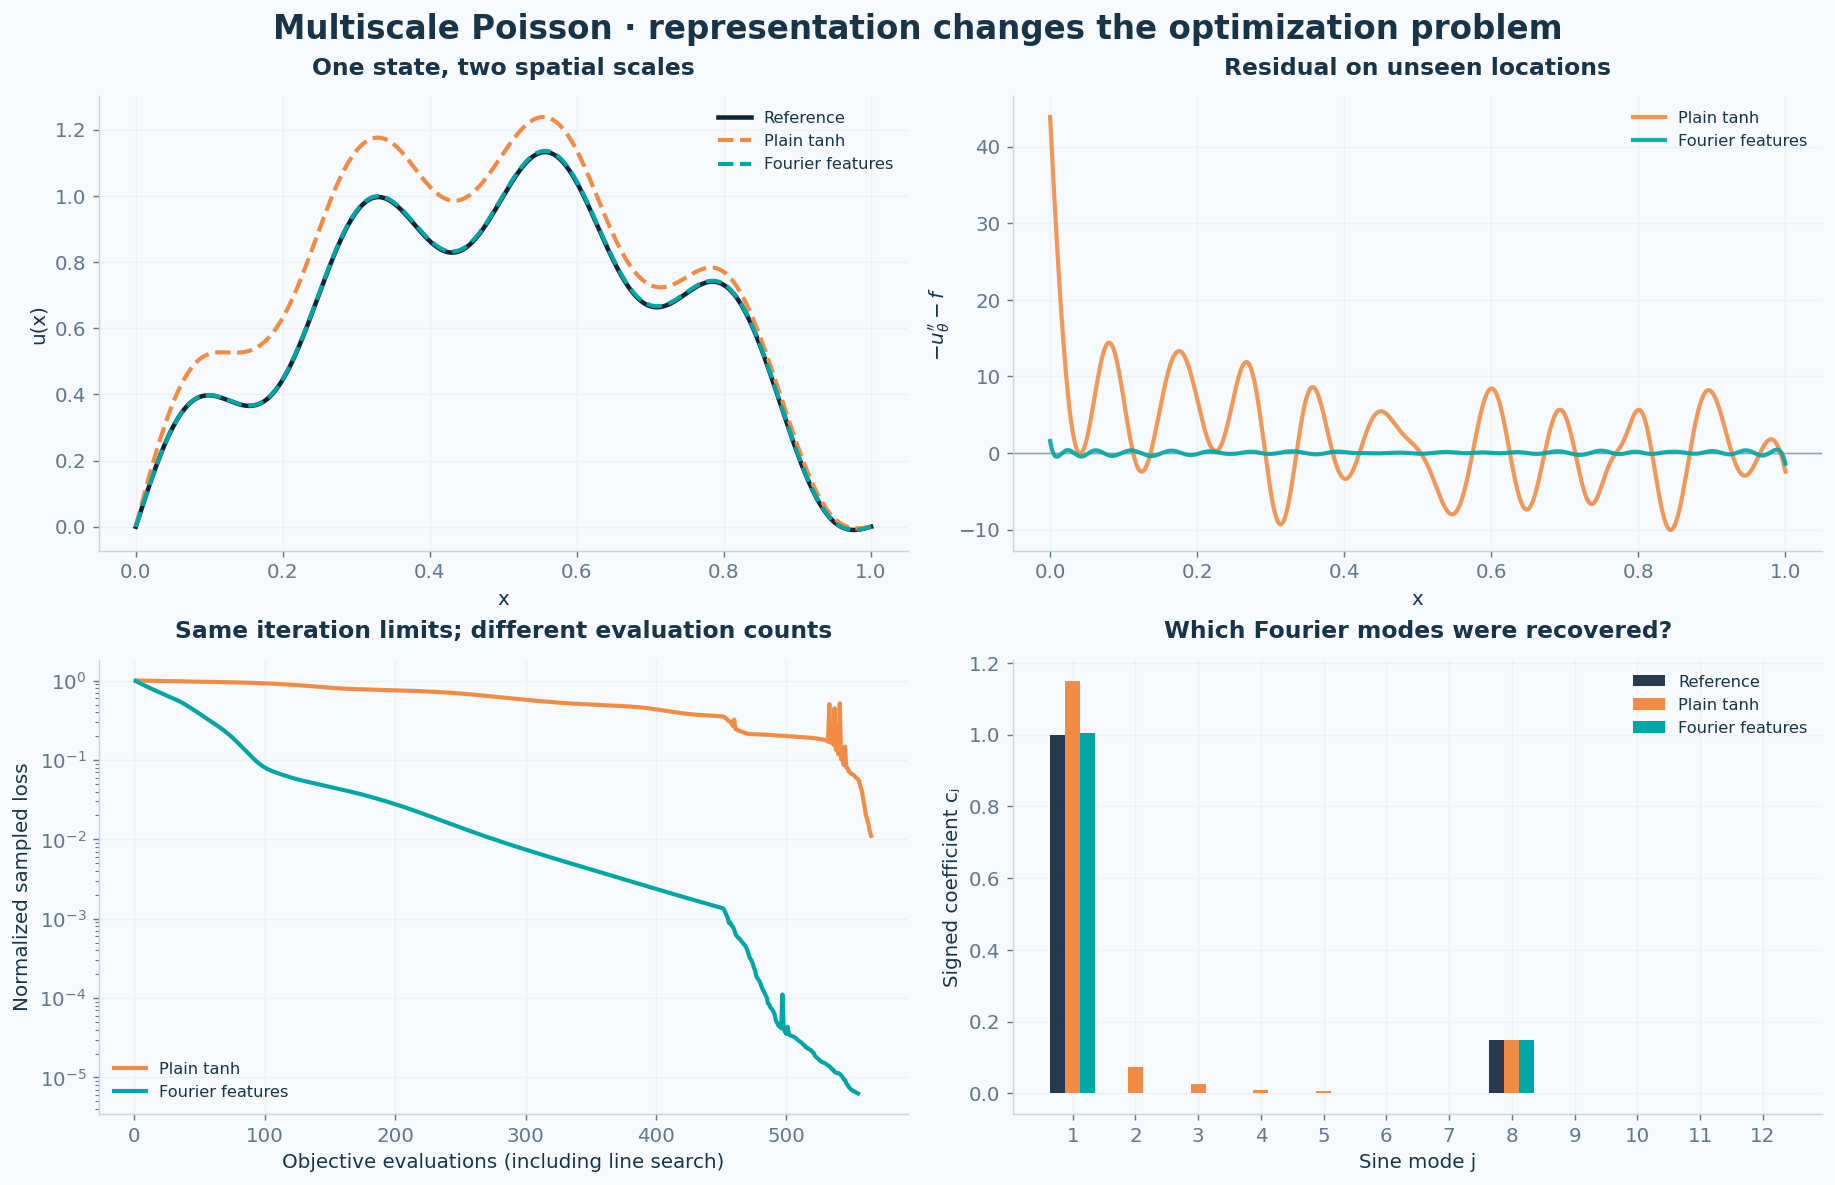

In [6]:
ms_colors = {"Plain tanh": palette["orange"], "Fourier features": palette["teal"]}
ms_fig, ms_axes = plt.subplots(2, 2, figsize=(14, 9), layout="constrained")
ms_axes[0, 0].plot(ms_test_x, ms_reference, color=palette["navy"], lw=2.5, label="Reference")
for ms_name, ms_result in ms_results.items():
    ms_color = ms_colors[ms_name]
    ms_axes[0, 0].plot(ms_test_x, ms_result["prediction"], color=ms_color, ls="--", label=ms_name)
    ms_axes[0, 1].plot(ms_test_x, ms_result["residual"], color=ms_color, alpha=.9, label=ms_name)
    ms_axes[1, 0].semilogy(ms_result["history"]["evaluation"], ms_result["history"]["loss"],
                          color=ms_color, label=ms_name)
ms_axes[0, 0].set(title="One state, two spatial scales", xlabel="x", ylabel="u(x)")
ms_axes[0, 1].set(title="Residual on unseen locations", xlabel="x", ylabel=r"$-u_\theta''-f$")
ms_axes[0, 1].axhline(0., color=palette["muted"], lw=.8, zorder=0)
ms_axes[1, 0].set(title="Same iteration limits; different evaluation counts",
                 xlabel="Objective evaluations (including line search)", ylabel="Normalized sampled loss")
ms_bar_width = .24
ms_axes[1, 1].bar(ms_modes-ms_bar_width, ms_reference_modes, width=ms_bar_width,
                  color=palette["navy"], label="Reference", alpha=.9)
for ms_offset, (ms_name, ms_result) in zip([0., ms_bar_width], ms_results.items()):
    ms_axes[1, 1].bar(ms_modes+ms_offset, ms_result["modal_snapshots"][-1], width=ms_bar_width,
                      color=ms_colors[ms_name], label=ms_name)
ms_axes[1, 1].set(title="Which Fourier modes were recovered?", xlabel="Sine mode j",
                 ylabel="Signed coefficient cⱼ", xticks=ms_modes)
for ms_ax in ms_axes.ravel():
    ms_ax.grid(alpha=.4); ms_ax.set_axisbelow(True); ms_ax.legend(fontsize=9)
ms_fig.suptitle("Multiscale Poisson · representation changes the optimization problem",
                fontsize=18, weight="bold")
save_figure(ms_fig, "10_multiscale_comparison")

In [7]:
# Rotate the learning history: height is a recovered sine coefficient, not a PDE time axis.
ms_surfaces = []
for ms_index, (ms_name, ms_result) in enumerate(ms_results.items()):
    ms_surfaces.append(go.Surface(x=ms_modes, y=ms_result["snapshot_evaluations"],
        z=ms_result["modal_snapshots"], visible=(ms_index == 0), colorscale="Viridis",
        colorbar=dict(title="Coefficient cⱼ"), name=ms_name,
        hovertemplate="Mode j=%{x}<br>Objective evaluations=%{y}<br>Coefficient=%{z:.4f}<extra></extra>"))
ms_learning_fig = go.Figure(ms_surfaces)
ms_learning_fig.update_layout(title="Mode recovery during training · Plain tanh",
    scene=dict(xaxis_title="Sine mode j", yaxis_title="Loss evaluations",
               zaxis_title="Coefficient cⱼ", aspectratio=dict(x=1, y=1, z=.7),
               camera=dict(eye=dict(x=1.65, y=1.65, z=1.4))),
    updatemenus=[dict(type="buttons", direction="left", buttons=[
        dict(label=ms_name, method="update", args=[
            {"visible": [ms_index == j for j in range(2)]},
            {"title.text": f"Mode recovery during training · {ms_name}"}])
        for ms_index, ms_name in enumerate(ms_results)])])
show_interactive(ms_learning_fig, "10_multiscale_learning")

[Open interactive explorer](notebook_outputs/10_multiscale_learning.html) — open locally in a browser; GitHub previews show the static plots.

In [8]:
for ms_name, ms_result in ms_results.items():
    metrics.append(dict(experiment=f"Multiscale: {ms_name}",
        relative_l2=ms_result["relative_l2"], residual_rms=ms_result["residual_rms"],
        parameters=ms_result["parameters"], seconds=ms_result["history"]["seconds"],
        objective_evaluations=len(ms_result["history"]["loss"]),
        boundary_max_abs=ms_result["boundary_max_abs"],
        mode_1=float(ms_result["modal_snapshots"][-1, 0]),
        mode_8=float(ms_result["modal_snapshots"][-1, 7])))
print("Recovered [slow mode, fast mode]; reference is [1.0, 0.15]:")
for ms_name, ms_result in ms_results.items():
    print(f"  {ms_name:17s}: {ms_result['modal_snapshots'][-1, [0, 7]]}")
print(json.dumps(MULTISCALE_SETTINGS, indent=2))

Recovered [slow mode, fast mode]; reference is [1.0, 0.15]:
  Plain tanh       : [1.15116892 0.14886945]
  Fourier features : [1.00355739 0.15000214]
{
  "seed": 314,
  "k": 8,
  "amplitude": 0.15,
  "feature_frequencies": [
    1.0,
    2.0,
    3.0
  ],
  "points": 128,
  "sampling": "fixed interior midpoints",
  "width": 24,
  "hidden_layers": 2,
  "adam_steps": 450,
  "adam_learning_rate": 0.002,
  "lbfgs_max_iter": 100,
  "residual_normalization": 67.35959813095556,
  "exact_boundary_factor": "x*(1-x)",
  "device": "cpu",
  "dtype": "float64",
  "threads": 1,
  "parameter_counts": {
    "Plain tanh": 673,
    "Fourier features": 817
  }
}


## 11 · Choosing collocation points from the residual

A narrow solution feature can be missed by a small, fixed collocation set. We manufacture
the smooth solution
$$u(x)=4x(1-x)\exp\!\left[-\left(\frac{x-0.63}{0.025}\right)^2\right],
\qquad -u''=f,\qquad u(0)=u(1)=0.$$
The forcing $f$ is differentiated analytically from this expression. **No solution values
enter training.** We compare fixed uniform points, uniformly refreshed points, and
residual-adaptive points. The refreshed-uniform control separates the benefit of moving
points from the benefit of using residual information.

To isolate sampling from difficult hidden-layer optimization, use a **fixed sine hidden
layer with trainable output weights**:
$$u_\theta(x)=s\sum_{k=1}^{64}\theta_k\frac{\sin(k\pi x)}{(k\pi)^2}.$$
This is also a spectral trial space. We keep the sine features fixed and train
only their output weights. The inverse-eigenvalue scaling makes the
normalized residual linear in the sine features. All three runs share initial weights,
initial points, point count, Adam updates, and learning-rate schedule.

In [9]:
ADAPTIVE_SETTINGS = dict(seed=71, points_per_step=40, candidate_count=1000,
    hidden_features=64, stages=24, steps_per_stage=100 if RUN_MODE == "quick" else 200,
    learning_rate=0.015, stage_lr_decay=0.75, uniform_mixture=0.35,
    center=0.63, width=0.025, residual_scale=1000.0)
ad_cfg = ADAPTIVE_SETTINGS
ad_dtype = torch.float64
ad_freq = torch.arange(1, ad_cfg["hidden_features"] + 1, dtype=ad_dtype)[None, :] * np.pi
ad_candidates = torch.tensor((np.arange(ad_cfg["candidate_count"]) + 0.5)[:, None]
                             / ad_cfg["candidate_count"], dtype=ad_dtype)
ad_x = np.linspace(0.0, 1.0, 1601)  # independent validation grid
ad_xt = torch.tensor(ad_x[:, None], dtype=ad_dtype)

def ad_reference(ad_input):
    ad_z = (ad_input - ad_cfg["center"]) / ad_cfg["width"]
    return 4 * ad_input * (1 - ad_input) * torch.exp(-ad_z.square())

def ad_forcing(ad_input):
    ad_w = ad_cfg["width"]
    ad_z = (ad_input - ad_cfg["center"]) / ad_w
    return -4 * torch.exp(-ad_z.square()) * (
        -2 - 4 * (1 - 2 * ad_input) * ad_z / ad_w
        + ad_input * (1 - ad_input) * (4 * ad_z.square() - 2) / ad_w**2)

class ad_SineNetwork(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.output_weights = torch.nn.Parameter(
            0.001 * torch.randn(ad_cfg["hidden_features"], 1, dtype=ad_dtype))

    def forward(self, ad_input):
        return ad_cfg["residual_scale"] * (
            torch.sin(ad_input * ad_freq) / ad_freq.square()) @ self.output_weights

# Cached fixed hidden features reduce repeated work; no reference state labels are used.
ad_phi = torch.sin(ad_candidates * ad_freq)
ad_f = ad_forcing(ad_candidates) / ad_cfg["residual_scale"]
ad_val_phi = torch.sin(ad_xt * ad_freq)
ad_val_f = ad_forcing(ad_xt)
ad_exact = ad_reference(ad_xt).numpy().ravel()
ad_initial_indices = (np.arange(ad_cfg["points_per_step"]) * 25 + 12).astype(int)
assert ad_cfg["candidate_count"] == 25 * ad_cfg["points_per_step"]
torch.manual_seed(ad_cfg["seed"])
ad_initial_model = ad_SineNetwork()
ad_initial_weights = ad_initial_model.output_weights.detach().clone()

# Verify the manufactured forcing once, independently by automatic differentiation.
ad_check_x = torch.linspace(0.51, 0.76, 23, dtype=ad_dtype)[:, None].requires_grad_()
ad_check_u = ad_reference(ad_check_x)
ad_check_du = torch.autograd.grad(ad_check_u.sum(), ad_check_x, create_graph=True)[0]
ad_check_d2u = torch.autograd.grad(ad_check_du.sum(), ad_check_x)[0]
assert torch.allclose(-ad_check_d2u, ad_forcing(ad_check_x), rtol=1e-11, atol=1e-9)
print(f"Each run: {ad_cfg['points_per_step']} points/update, "
      f"{ad_cfg['stages'] * ad_cfg['steps_per_stage']} Adam updates, identical initialization.")

Each run: 40 points/update, 2400 Adam updates, identical initialization.


### Importance weights preserve the sampling objective

On a fixed uniform candidate grid of $M$ points, the target is
$\widehat{\mathcal J}_M(\theta)=M^{-1}\sum_i \widetilde r_\theta(x_i)^2$,
where $\widetilde r=r/s$. Before each new stage, form the frozen proposal
$$p_i=\frac{\alpha}{M}+(1-\alpha)
\frac{\widetilde r_{\rm old}(x_i)^2}{\sum_j\widetilde r_{\rm old}(x_j)^2},
\qquad\alpha=0.35.$$
Draw $N$ indices independently **with replacement**, then train for one stage on
$$\widehat{\mathcal J}_{\rm batch}(\theta)=\frac1N\sum_{b=1}^N
\frac{\widetilde r_\theta(x_{i_b})^2}{M p_{i_b}}.$$
For any fixed trial state, averaging over these draws recovers the uniform candidate
objective exactly. The proposal and importance weights stay frozen during the stage.
This expectation identity does **not** guarantee generalization after fitting a drawn
batch. The candidate objective itself is a numerical approximation to the continuum loss.
The mixture keeps every candidate selectable and bounds each weight by $1/\alpha$.

Adaptive sampling also scores all $M$ candidates between stages. We count those extra
residual evaluations and time the scans; equal training-point budgets are not equal total costs.

In [10]:
def ad_run(ad_method):
    ad_rng = np.random.default_rng(ad_cfg["seed"])
    ad_model = ad_SineNetwork()
    with torch.no_grad():
        ad_model.output_weights.copy_(ad_initial_weights)
    ad_optimizer = torch.optim.Adam(ad_model.parameters(), lr=ad_cfg["learning_rate"])
    ad_indices = ad_initial_indices.copy()
    ad_weights = torch.ones((ad_cfg["points_per_step"], 1), dtype=ad_dtype)
    ad_hist = dict(relative_l2=[], residual_rms=[], sampled_loss=[], points=[], residual_map=[])
    ad_search_seconds, ad_scored_points = 0.0, 0
    ad_start = time.perf_counter()
    for ad_stage in range(ad_cfg["stages"]):
        for ad_group in ad_optimizer.param_groups:
            ad_group["lr"] = ad_cfg["learning_rate"] * ad_cfg["stage_lr_decay"]**ad_stage
        if ad_stage > 0 and ad_method != "Fixed uniform":
            if ad_method == "Residual adaptive":
                ad_search_start = time.perf_counter()
                with torch.no_grad():
                    ad_scores = (ad_phi @ ad_model.output_weights - ad_f).square().numpy().ravel()
                ad_prob = np.full(ad_cfg["candidate_count"], 1 / ad_cfg["candidate_count"])
                if ad_scores.sum() > 0:
                    ad_prob = (ad_cfg["uniform_mixture"] * ad_prob
                               + (1 - ad_cfg["uniform_mixture"]) * ad_scores / ad_scores.sum())
                ad_search_seconds += time.perf_counter() - ad_search_start
                ad_scored_points += ad_cfg["candidate_count"]
            else:
                ad_prob = np.full(ad_cfg["candidate_count"], 1 / ad_cfg["candidate_count"])
            ad_indices = ad_rng.choice(ad_cfg["candidate_count"], ad_cfg["points_per_step"],
                                       replace=True, p=ad_prob)
            ad_weights = torch.tensor((1 / (ad_cfg["candidate_count"] * ad_prob[ad_indices]))[:, None],
                                      dtype=ad_dtype)
        ad_batch_phi, ad_batch_f = ad_phi[ad_indices], ad_f[ad_indices]
        for ad_step in range(ad_cfg["steps_per_stage"]):
            ad_optimizer.zero_grad(set_to_none=True)
            ad_batch_r = ad_batch_phi @ ad_model.output_weights - ad_batch_f
            ad_loss = (ad_weights * ad_batch_r.square()).mean()
            ad_loss.backward()
            ad_optimizer.step()
        with torch.no_grad():
            ad_prediction = ad_model(ad_xt).numpy().ravel()
            ad_residual = (ad_cfg["residual_scale"] * ad_val_phi @ ad_model.output_weights
                           - ad_val_f).numpy().ravel()
            ad_err = np.sqrt(np.trapezoid((ad_prediction - ad_exact)**2, ad_x)
                             / np.trapezoid(ad_exact**2, ad_x))
            ad_rms = np.sqrt(np.trapezoid(ad_residual**2, ad_x))
            ad_final_batch = ad_batch_phi @ ad_model.output_weights - ad_batch_f
            ad_hist["sampled_loss"].append(float((ad_weights * ad_final_batch.square()).mean()))
        ad_hist["relative_l2"].append(float(ad_err))
        ad_hist["residual_rms"].append(float(ad_rms))
        ad_hist["points"].append(ad_candidates[ad_indices].numpy().ravel())
        ad_hist["residual_map"].append(ad_residual[::8] / ad_cfg["residual_scale"])
    ad_seconds = time.perf_counter() - ad_start
    return dict(prediction=ad_prediction, residual=ad_residual, relative_l2=float(ad_err),
        residual_rms=float(ad_rms), history=ad_hist, seconds=ad_seconds,
        candidate_scan_seconds=ad_search_seconds, extra_candidate_evaluations=ad_scored_points,
        training_point_evaluations=ad_cfg["points_per_step"] * ad_cfg["stages"] * ad_cfg["steps_per_stage"])

ad_results = {}
for ad_label in ["Fixed uniform", "Uniform refresh", "Residual adaptive"]:
    ad_result = ad_run(ad_label)
    ad_results[ad_label] = ad_result
    metrics.append(dict(experiment=f"Adaptive sampling / {ad_label}",
        relative_l2=ad_result["relative_l2"], seconds=ad_result["seconds"],
        residual_rms=ad_result["residual_rms"],
        extra_candidate_evaluations=ad_result["extra_candidate_evaluations"]))
    print(f"{ad_label:18s} | relative L2 {ad_result['relative_l2']:.2%} | "
          f"physical residual RMS {ad_result['residual_rms']:.3f} | {ad_result['seconds']:.2f} s")
print("Per run: %d training-point evaluations." % ad_result["training_point_evaluations"])
print("Adaptive extras: %d candidate residuals; %.4f s of scoring + proposal construction." % (
    ad_results["Residual adaptive"]["extra_candidate_evaluations"],
    ad_results["Residual adaptive"]["candidate_scan_seconds"]))
print("Times include identical validation schedules. Candidates and fixed features were cached once.")

Fixed uniform      | relative L2 27.08% | physical residual RMS 333.512 | 0.49 s


Uniform refresh    | relative L2 17.22% | physical residual RMS 5.255 | 0.95 s


Residual adaptive  | relative L2 7.10% | physical residual RMS 5.088 | 0.46 s
Per run: 96000 training-point evaluations.
Adaptive extras: 23000 candidate residuals; 0.0018 s of scoring + proposal construction.
Times include identical validation schedules. Candidates and fixed features were cached once.


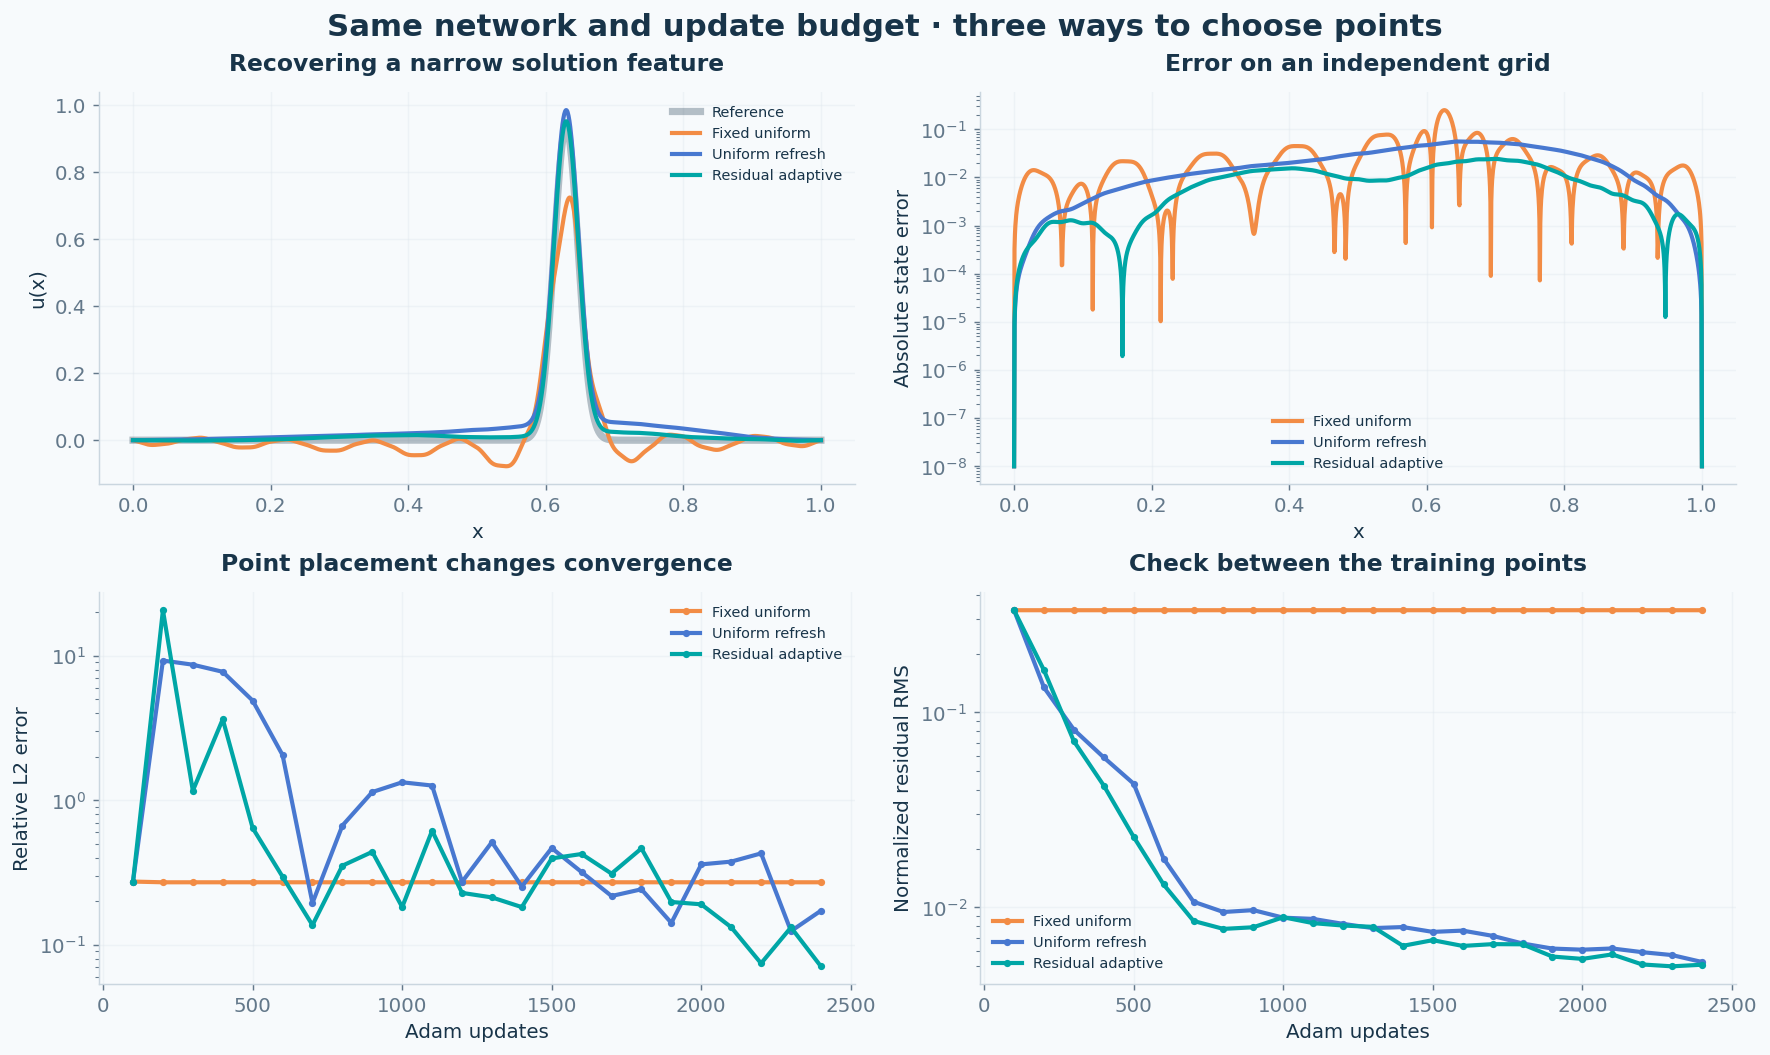

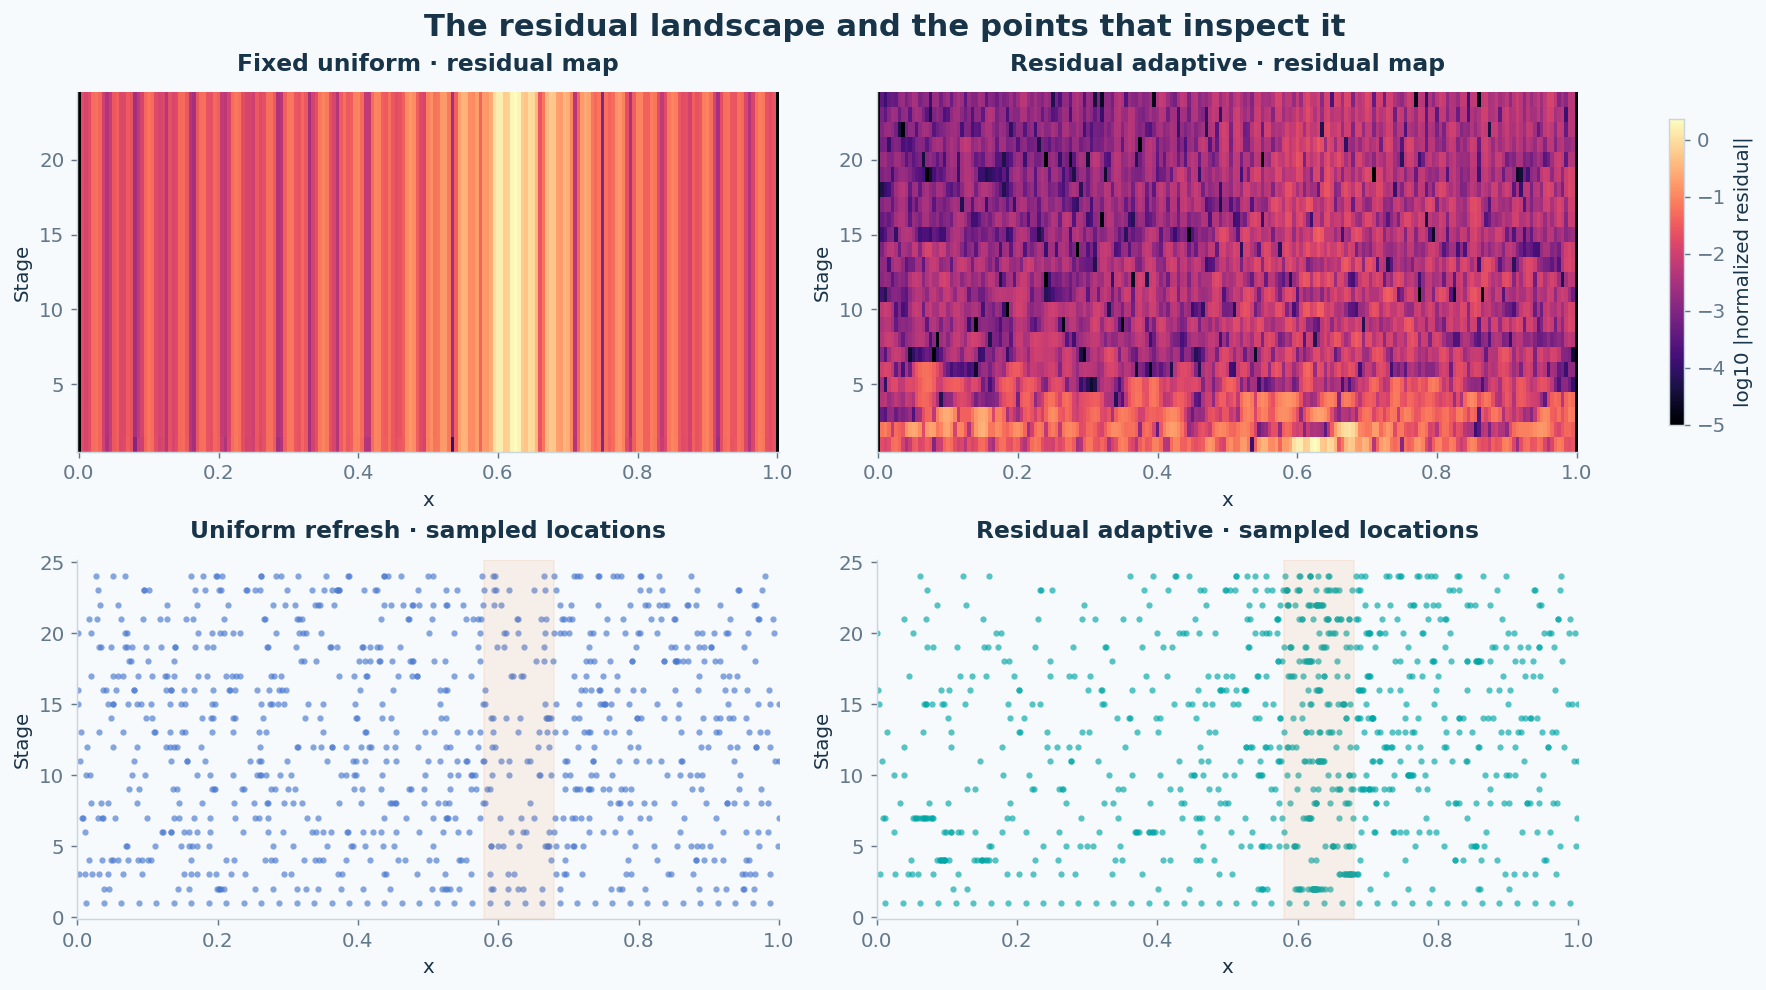

In [11]:
ad_colors = {"Fixed uniform": palette["orange"], "Uniform refresh": palette["blue"],
             "Residual adaptive": palette["teal"]}
ad_steps = (np.arange(ad_cfg["stages"]) + 1) * ad_cfg["steps_per_stage"]
ad_fig, ad_axes = plt.subplots(2, 2, figsize=(13.5, 8.0), layout="constrained")
ad_axes[0, 0].plot(ad_x, ad_exact, color=palette["ink"], lw=4, alpha=0.3, label="Reference")
for ad_label, ad_result in ad_results.items():
    ad_color = ad_colors[ad_label]
    ad_axes[0, 0].plot(ad_x, ad_result["prediction"], color=ad_color, label=ad_label)
    ad_axes[0, 1].semilogy(ad_x, np.maximum(np.abs(ad_result["prediction"] - ad_exact), 1e-8),
                         color=ad_color, label=ad_label)
    ad_axes[1, 0].semilogy(ad_steps, ad_result["history"]["relative_l2"], "o-",
                         color=ad_color, ms=3, label=ad_label)
    ad_axes[1, 1].semilogy(ad_steps, np.asarray(ad_result["history"]["residual_rms"]) /
                         ad_cfg["residual_scale"], "o-", color=ad_color, ms=3, label=ad_label)
ad_axes[0, 0].set(title="Recovering a narrow solution feature", xlabel="x", ylabel="u(x)")
ad_axes[0, 1].set(title="Error on an independent grid", xlabel="x", ylabel="Absolute state error")
ad_axes[1, 0].set(title="Point placement changes convergence", xlabel="Adam updates", ylabel="Relative L2 error")
ad_axes[1, 1].set(title="Check between the training points", xlabel="Adam updates", ylabel="Normalized residual RMS")
for ad_ax in ad_axes.ravel():
    ad_ax.grid(alpha=0.35)
    ad_ax.legend(fontsize=8)
ad_fig.suptitle("Same network and update budget · three ways to choose points", fontsize=17, weight="bold")
save_figure(ad_fig, "11_adaptive_accuracy")

ad_fig, ad_axes = plt.subplots(2, 2, figsize=(13.5, 7.5), layout="constrained")
ad_map_x = ad_x[::8]
ad_maps = {ad_label: np.log10(np.maximum(np.abs(np.asarray(ad_result["history"]["residual_map"])), 1e-5))
           for ad_label, ad_result in ad_results.items()}
ad_vmax = max(float(ad_map.max()) for ad_map in ad_maps.values())
for ad_ax, ad_label in zip(ad_axes[0], ["Fixed uniform", "Residual adaptive"]):
    ad_im = ad_ax.pcolormesh(ad_map_x, np.arange(1, ad_cfg["stages"] + 1), ad_maps[ad_label],
                            shading="nearest", cmap="magma", vmin=-5, vmax=ad_vmax)
    ad_ax.set(title=f"{ad_label} · residual map", xlabel="x", ylabel="Stage")
ad_fig.colorbar(ad_im, ax=list(ad_axes[0]), label="log10 |normalized residual|", shrink=0.85)
for ad_ax, ad_label in zip(ad_axes[1], ["Uniform refresh", "Residual adaptive"]):
    for ad_stage, ad_points in enumerate(ad_results[ad_label]["history"]["points"], start=1):
        ad_ax.scatter(ad_points, np.full_like(ad_points, ad_stage), s=12, alpha=0.65,
                       color=ad_colors[ad_label], linewidths=0)
    ad_ax.axvspan(ad_cfg["center"] - 2 * ad_cfg["width"],
                  ad_cfg["center"] + 2 * ad_cfg["width"], color=palette["orange"], alpha=0.10)
    ad_ax.set(title=f"{ad_label} · sampled locations", xlabel="x", ylabel="Stage", xlim=(0, 1))
ad_fig.suptitle("The residual landscape and the points that inspect it", fontsize=17, weight="bold")
save_figure(ad_fig, "11_adaptive_sampling_maps")

Forty fixed points undersample this 64-feature trial space;
a tiny loss on those points can coexist with a large residual elsewhere. Uniform refresh
is therefore an essential baseline. The adaptive run can focus effort where the current
model is wrong while the importance weights preserve its *expected* candidate objective.
Inspect the stages where progress stalls or reverses, and repeat with other seeds
to see how stable the comparison is.

The extra candidate scans use 23,000 residual evaluations in quick mode, on top of 96,000
training-point evaluations. Cached sine features make those scans inexpensive here;
second derivatives through a fully trainable network can make searching much more costly.
The timing includes the same validation schedule for every method.

**Try:** (1) increase the fixed-point count and adjust the candidate-grid ratio; (2) replace
residual-adaptive probabilities by uniform probabilities and check the importance weights
become one; (3) repeat with several seeds before drawing a method comparison; (4) reduce
the uniform mixture and inspect both maximum weight and training stability; (5) increase
the number of sine features and ask whether sampling or approximation now limits accuracy.

## Save this notebook's results

This cell records versions, settings, diagnostics and computed fields, and builds a
local gallery. Report filenames include this notebook's part number, so notebooks
can run independently in any order without overwriting each other's reports.

In [12]:
# Keep reports separate so running one notebook cannot replace another's results.
PART = '06_features_and_sampling'
summary_metrics = list(metrics)

report = dict(part=PART, versions=versions, run_mode=RUN_MODE, seed=SEED, budgets=BUDGET,
    device="cpu", dtype=str(torch.get_default_dtype()), settings=dict(multiscale=MULTISCALE_SETTINGS, adaptive=ADAPTIVE_SETTINGS),
    static_figures=FIGURE_NAMES, interactive_figures=INTERACTIVE_NAMES,
    metrics=summary_metrics, elapsed_seconds=time.perf_counter()-NOTEBOOK_START)
(OUTPUT_DIR / f"run_summary_{PART}.json").write_text(json.dumps(report, indent=2))
np.savez_compressed(OUTPUT_DIR / f"computed_fields_{PART}.npz", multiscale_x=ms_test_x, multiscale_exact=ms_reference,
        multiscale_plain=ms_results["Plain tanh"]["prediction"],
        multiscale_fourier=ms_results["Fourier features"]["prediction"],
        adaptive_x=ad_x, adaptive_exact=ad_exact,
        adaptive_labels=np.array(list(ad_results)),
        adaptive_predictions=np.stack([r["prediction"] for r in ad_results.values()]),
        adaptive_residuals=np.stack([r["residual"] for r in ad_results.values()]))

from html import escape
cards = []
for name in FIGURE_NAMES:
    title = escape(name.replace("_", " ").title())
    cards.append(f'<figure><a href="{name}.png"><img src="{name}.png" alt="{title}"></a>'
                 f'<figcaption>{title} · <a href="{name}.pdf">PDF</a></figcaption></figure>')
links = "".join(f'<li><a href="{name}.html">{escape(name.replace("_", " ").title())}</a></li>'
                for name in INTERACTIVE_NAMES)
page = ('<!doctype html><html lang="en"><meta charset="utf-8">'
        '<meta name="viewport" content="width=device-width, initial-scale=1">'
        '<title>Neural PDE Laboratory</title><style>'
        'body{font-family:system-ui;color:#273442;max-width:1100px;margin:auto;padding:32px}'
        'img{max-width:100%}figure{margin:32px 0}a{color:#4d708a}</style>'
        f'<h1>Neural PDE Laboratory · {escape(PART)}</h1><ul>' + links + '</ul>' + "".join(cards) + '</html>')
(OUTPUT_DIR / f"index_{PART}.html").write_text(page)
print(f"Completed in {report['elapsed_seconds']:.1f} seconds.")
print(f"Saved {len(FIGURE_NAMES)} figure sets and {len(INTERACTIVE_NAMES)} interactive explorers.")
print(f"Reports: run_summary_{PART}.json, computed_fields_{PART}.npz, index_{PART}.html")
for row in summary_metrics:
    print(f"{row['experiment']:32s} relative L2 = {row['relative_l2']:.3e}")

Completed in 19.7 seconds.
Saved 3 figure sets and 1 interactive explorers.
Reports: run_summary_06_features_and_sampling.json, computed_fields_06_features_and_sampling.npz, index_06_features_and_sampling.html
Multiscale: Plain tanh           relative L2 = 1.681e-01
Multiscale: Fourier features     relative L2 = 3.544e-03
Adaptive sampling / Fixed uniform relative L2 = 2.708e-01
Adaptive sampling / Uniform refresh relative L2 = 1.722e-01
Adaptive sampling / Residual adaptive relative L2 = 7.098e-02


[Previous notebook](Neural_PDE_05_reaction_diffusion.ipynb) · [Laboratory index](Neural_PDE_Laboratory.ipynb) · [Next notebook](Neural_PDE_07_time_and_parameters.ipynb)